<a href="https://colab.research.google.com/github/Bronaps/taskmanager/blob/main/parcel_prediction_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcel Count Prediction — Clean Modeling & Evaluation Pipeline

Predict **`PARCELS_COUNT`** (boxes per order) and, above all, **report how wrong the
model is *per order*, broken down by order size** — the metric your stakeholders asked for.

This notebook is a cleaned, modular rebuild of the original comprehensive notebook. It is
organised so you can **model → test → evaluate** through a small set of reusable helpers,
and **compare any number of models on identical metrics with one function call**.

### How it's organised
1. **Configuration & imports**
2. **Data utilities** — small shared helpers
3. **Build / load the order-level table** — your existing pipeline, refactored (plus a synthetic `demo` mode so the framework runs with no files)
4. **Feature engineering**
5. **Feature columns & the data bundle** — one object passed to every model
6. **Evaluation toolkit** — ⭐ the per-band signed % error profile + standard metrics
7. **Modeling toolkit** — baselines and XGBoost behind one interface
8. **`compare_models()`** — the single function that trains many models and scores them identically
9. **Worked example** — define several models, compare, then drill into the winner
10. **Hyperparameter search** — emits configs that feed straight back into the comparison
11. **Permutation importance**
12. **Export** — model, metadata, and a reusable `prepare_features` template

> The reusable contract is simple: every model is an object with a `.name` and a
> `.fit_predict(data) -> np.ndarray` method, and every evaluation function takes
> `(y_true, y_pred)`. That is the whole framework.

## 1. Configuration

`DATA_MODE` controls where the order-level table comes from:
- `"raw"` — rebuild from the original command CSVs + product catalogue (your pipeline),
- `"order_level"` — load an already-prepared table from `ORDER_LEVEL_PATH`,
- `"demo"` — generate synthetic orders so the whole notebook runs with no external files
  (use this to learn the framework, then switch to `"raw"`/`"order_level"`).

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# ============================================================
# CONFIGURATION
# ============================================================
DATA_MODE = "raw"          # "raw" | "order_level" | "demo"
RUN_IN_COLAB = False        # True mounts Google Drive
XGB_DEVICE = "cuda"          # "cuda" on a GPU runtime, else "cpu"

# Raw data paths (only used when DATA_MODE == "raw")
DATA_ROOT     = "/content/drive/MyDrive/Klareo/Klareo_export/Data export pour Leclerc"
COMMANDES_DIR = f"{DATA_ROOT}/Commandes bon format"
PRODUCTS_PATH = f"{DATA_ROOT}/Référentiel articles/dim_produits.xlsx"
AFFECTATIONS_PATH         = f"{COMMANDES_DIR}/Affectations/affectations_997371_Parinordis_2026-06-04 (1).csv"
AFFECTATIONS_PRODUIT_PATH = f"{COMMANDES_DIR}/Affectations/affectations_produit_997371_Parinordis_2026-06-04 (1).csv"
USE_AFFECTATIONS = True

# Prepared table (only used when DATA_MODE == "order_level")
ORDER_LEVEL_PATH = f"{DATA_ROOT}/orders_features.csv"

# Save the prepared table after a raw build
SAVE_ORDER_LEVEL_DATASET = True
ORDER_LEVEL_EXPORT_PATH  = f"{DATA_ROOT}/orders_features_prepared.csv"
MODEL_EXPORT_DIR         = DATA_ROOT

CSV_SEPARATOR = ";"
TARGET        = "PARCELS_COUNT"
RANDOM_STATE  = 42

## 2. Imports

In [19]:
# ============================================================
# IMPORTS
# ============================================================
import os, gc, re, pickle, warnings, unicodedata, itertools
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

try:
    from IPython.display import display
except Exception:
    display = print

if RUN_IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Colab Drive mount skipped:", e)

print("Libraries loaded. xgboost", xgb.__version__)

Libraries loaded. xgboost 3.2.0


## 3. Data utilities

Small shared helpers, unchanged in spirit from the original: accent-robust strings,
comma-separated counting (for `EAN_PARCELS` / `EAN_PRODUITS`), a duplicate-safe quantile cut,
and a section printer.

In [20]:
# ============================================================
# DATA UTILITIES
# ============================================================
def strip_accents(text):
    if pd.isna(text):
        return ""
    return unicodedata.normalize("NFD", str(text)).encode("ascii", "ignore").decode("utf-8")

def count_comma_separated_values(x):
    """Count non-empty comma-separated values; 0 for missing."""
    if pd.isna(x):
        return 0
    vals = [v.strip() for v in str(x).split(",")]
    return len([v for v in vals if v and v.lower() not in {"nan", "none", "null"}])

def safe_qcut(series, q=10):
    return pd.qcut(series, q=q, duplicates="drop")

def display_section(title):
    print("\n" + "=" * 88 + f"\n{title}\n" + "=" * 88)

## 4. Build / load the order-level table

`build_order_level_table()` is your original raw pipeline, refactored into one function with
the same logic: load the command CSVs, derive the target from `EAN_PARCELS`, explode
`EAN_PRODUITS`, merge the product catalogue on `CODE_EAN_PRINCIPAL`, and aggregate to **one row
per order** with physical, family, affectation (zone) and delivery/date features. It also derives
the segregation-based `parcel_lower_bound` from the rule itself (no hardcoded zone codes).

`make_synthetic_orders()` fabricates a structurally similar table for `DATA_MODE="demo"` so every
downstream cell runs unchanged.

In [26]:
# ============================================================
# RAW PIPELINE  (DATA_MODE == "raw")  — refactored, same logic
# ============================================================
def _slug(s):
    s = str(s).split("—")[0].strip()
    return re.sub(r"[^0-9A-Za-zÀ-ÿ]+", "_", s).strip("_")

def build_order_level_table(commandes_dir, products_path, csv_sep=";",
                            use_affectations=True,
                            affectations_path=None, affectations_produit_path=None):
    # ---- 1. load + concat raw order files ----
    csv_files = sorted(f for f in os.listdir(commandes_dir) if f.lower().endswith(".csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files in {commandes_dir}")
    combined = pd.concat(
        [pd.read_csv(os.path.join(commandes_dir, f), delimiter=csv_sep, on_bad_lines="warn")
             .assign(SOURCE_FILE=f) for f in csv_files],
        ignore_index=True)

    required = ["ORDER_NUMBER", "EAN_PRODUITS", "EAN_PARCELS"]
    missing = [c for c in required if c not in combined.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    combined = combined.dropna(subset=["EAN_PRODUITS", "EAN_PARCELS"]).reset_index(drop=True)

    # ---- 2. target + date features ----
    combined[TARGET] = combined["EAN_PARCELS"].apply(count_comma_separated_values)
    if "DATE_LIVRAISON" in combined.columns:
        combined["DATE_LIVRAISON"] = pd.to_datetime(combined["DATE_LIVRAISON"],
                                                    errors="coerce", dayfirst=True)
        combined["day_of_week"] = combined["DATE_LIVRAISON"].dt.dayofweek.fillna(-1).astype(int)
        combined["is_weekend"]  = (combined["day_of_week"].isin([5, 6])).astype(int)
        combined["day_unknown"] = (combined["day_of_week"] == -1).astype(int)

    # ---- 3. product catalogue ----
    produits = pd.read_excel(products_path).drop(
        columns=["ACTIF_O_N", "PRDT_REGIONAL_O_N", "TYPE_AG"], errors="ignore")
    dim_cols = ["largeur_cm", "hauteur_cm", "profondeur_cm",
                "poids_brut_g", "poids_net_g", "volume_calcule_litre"]
    for c in ["largeur_cm", "hauteur_cm", "profondeur_cm", "poids_brut_g", "poids_net_g"]:
        produits[c] = produits.get(c, np.nan)
    if "volume_calcule_litre" not in produits.columns:
        produits["volume_calcule_litre"] = (produits["largeur_cm"] * produits["hauteur_cm"]
                                            * produits["profondeur_cm"] / 1000)
    for c in dim_cols:
        produits[c] = pd.to_numeric(produits[c], errors="coerce")
    produits["CODE_EAN_PRINCIPAL"] = pd.to_numeric(produits["CODE_EAN_PRINCIPAL"], errors="coerce")
    produits = produits.dropna(subset=["CODE_EAN_PRINCIPAL"])
    produits["CODE_EAN_PRINCIPAL"] = produits["CODE_EAN_PRINCIPAL"].astype("int64")

    # ---- 4. explode order products + merge catalogue ----
    combined["EAN_LIST"] = combined["EAN_PRODUITS"].astype(str).str.split(",")
    exploded = combined.explode("EAN_LIST")
    exploded["EAN_LIST"] = exploded["EAN_LIST"].astype(str).str.strip()
    exploded = exploded[exploded["EAN_LIST"] != ""]
    exploded["EAN_NUM"] = pd.to_numeric(exploded["EAN_LIST"], errors="coerce")
    exploded = exploded.dropna(subset=["EAN_NUM"])
    exploded["EAN_NUM"] = exploded["EAN_NUM"].astype("int64")
    merged = exploded.merge(produits, left_on="EAN_NUM",
                            right_on="CODE_EAN_PRINCIPAL", how="left")
    for c in dim_cols:
        merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(0)
    print(f"Catalogue match rate: {merged['CODE_EAN_PRINCIPAL'].notna().mean()*100:.2f}%")

    # ---- 5. physical features (vectorised) ----
    merged["item_max_dim_cm"] = merged[["largeur_cm", "hauteur_cm", "profondeur_cm"]].max(axis=1)
    merged["is_bulky"]     = (merged["volume_calcule_litre"] > 5).astype(int)
    merged["is_heavy"]     = (merged["poids_brut_g"] > 1000).astype(int)
    merged["is_long"]      = (merged["item_max_dim_cm"] > 50).astype(int)
    merged["is_unmatched"] = merged["CODE_EAN_PRINCIPAL"].isna().astype(int)
    physical = merged.groupby("ORDER_NUMBER").agg(
        total_weight_brut_g=("poids_brut_g", "sum"),
        total_weight_net_g=("poids_net_g", "sum"),
        total_volume_l=("volume_calcule_litre", "sum"),
        max_dim_cm=("item_max_dim_cm", "max"),
        std_item_volume_l=("volume_calcule_litre", "std"),
        std_item_weight_g=("poids_brut_g", "std"),
        n_items=("EAN_NUM", "count"),
        n_bulky_items=("is_bulky", "sum"),
        n_heavy_items=("is_heavy", "sum"),
        n_long_items=("is_long", "sum"),
        n_unmatched=("is_unmatched", "sum"),
    ).reset_index()
    p95 = (merged.groupby("ORDER_NUMBER")["volume_calcule_litre"]
                 .quantile(0.95).rename("p95_item_volume_l").reset_index())
    physical = physical.merge(p95, on="ORDER_NUMBER", how="left").fillna(0)

    # ---- 6. family counts ----
    if "LIBELLE_RAYON" in merged.columns:
        fam = merged.pivot_table(index="ORDER_NUMBER", columns="LIBELLE_RAYON",
                                 values="EAN_NUM", aggfunc="count", fill_value=0).reset_index()
        fam.columns = ["ORDER_NUMBER"] + [f"fam_{c}" for c in fam.columns[1:]]
    else:
        fam = physical[["ORDER_NUMBER"]].copy()

    # ---- 7. affectation (zone) features + parcel_lower_bound ----
    aff = None
    if use_affectations:
        df_aff  = pd.read_csv(affectations_path, sep=csv_sep)
        df_affp = pd.read_csv(affectations_produit_path, sep=csv_sep)
        df_affp["EAN"] = pd.to_numeric(df_affp["EAN"], errors="coerce")
        amap = (df_affp.merge(df_aff, left_on="Code Affectation", right_on="Code", how="left")
                       .dropna(subset=["EAN"]).drop_duplicates("EAN"))
        seg = amap.drop_duplicates("Code Affectation")
        seg_mask = (seg["Discriminant"].astype(str).str.strip().str.lower().eq("oui")
                    | seg["Support"].astype(str).str.contains("sac", case=False, na=False))
        seg_codes = sorted(seg.loc[seg_mask, "Code Affectation"].dropna().astype(int).unique())
        print(f"Segregated (parcel-forcing) zones: {seg_codes}")

        order_aff = merged[["ORDER_NUMBER", "EAN_NUM"]].merge(
            amap[["EAN", "Code Affectation", "Libellé", "Support"]],
            left_on="EAN_NUM", right_on="EAN", how="left")
        counts = order_aff.pivot_table(index="ORDER_NUMBER", columns="Code Affectation",
                                       values="EAN_NUM", aggfunc="count", fill_value=0)
        counts.columns = [f"aff_{int(c)}_n" for c in counts.columns]
        counts = counts.reset_index()
        for c in [c for c in counts.columns if c.endswith("_n")]:
            counts[c.replace("_n", "_present")] = (counts[c] > 0).astype(int)
        present = [c for c in counts.columns if c.endswith("_present")]
        seg_present = [f"aff_{c}_present" for c in seg_codes if f"aff_{c}_present" in counts.columns]
        ambient = [c for c in present if c not in seg_present]
        counts["n_distinct_affectations"]   = counts[present].sum(axis=1)
        counts["n_segregated_affectations"] = counts[seg_present].sum(axis=1) if seg_present else 0
        counts["has_ambient_items"]         = (counts[ambient].sum(axis=1) > 0).astype(int) if ambient else 0
        counts["parcel_lower_bound"]        = counts["n_segregated_affectations"] + counts["has_ambient_items"]
        sup = order_aff.dropna(subset=["Support"]).copy()
        sup["support_clean"] = sup["Support"].map(_slug)
        sup_counts = (sup.pivot_table(index="ORDER_NUMBER", columns="support_clean",
                                      values="EAN_NUM", aggfunc="count", fill_value=0)
                         .add_prefix("support_").reset_index())
        aff = counts.merge(sup_counts, on="ORDER_NUMBER", how="left")

    # ---- 8. assemble ----
    meta_cols = [c for c in ["ORDER_NUMBER", "CODE_SITE", "TYPE_LIVRAISON", "DATE_LIVRAISON",
                             "SOURCE_FILE", "day_of_week", "is_weekend", "day_unknown", TARGET]
                 if c in combined.columns]
    orders = (combined[meta_cols].drop_duplicates("ORDER_NUMBER")
              .merge(physical, on="ORDER_NUMBER", how="left")
              .merge(fam, on="ORDER_NUMBER", how="left"))
    if aff is not None:
        orders = orders.merge(aff, on="ORDER_NUMBER", how="left")
    if "TYPE_LIVRAISON" in orders.columns:
        dummies = pd.get_dummies(orders["TYPE_LIVRAISON"], prefix="TYPE_LIVRAISON",
                                 dummy_na=False).astype(int)
        orders = pd.concat([orders, dummies], axis=1)
    return orders.fillna(0)

In [22]:
# ============================================================
# SYNTHETIC PIPELINE  (DATA_MODE == "demo")
# ============================================================
def make_synthetic_orders(n=8000, seed=RANDOM_STATE):
    """Fabricate an order-level table with the same shape and drivers as the real one,
    so the framework runs end-to-end with no external files."""
    rng = np.random.default_rng(seed)
    n_items = rng.integers(1, 60, size=n)
    avg_w   = rng.uniform(80, 1500, size=n)
    avg_v   = rng.uniform(0.2, 6.0, size=n)
    total_weight_brut_g = n_items * avg_w * rng.uniform(0.9, 1.1, size=n)
    total_volume_l      = n_items * avg_v * rng.uniform(0.9, 1.1, size=n)
    n_distinct_aff = rng.integers(1, 5, size=n)
    base = np.maximum.reduce([np.ceil(total_volume_l / 32.0),
                              np.ceil(total_weight_brut_g / 11000.0),
                              np.ceil(n_items / 18.0)])
    parcels = np.maximum(1, base + (n_distinct_aff - 1) +
                         rng.integers(-1, 2, size=n)).astype(int)
    return pd.DataFrame({
        "ORDER_NUMBER": np.arange(n),
        "n_items": n_items,
        "total_weight_brut_g": total_weight_brut_g,
        "total_weight_net_g": total_weight_brut_g * rng.uniform(0.8, 0.95, size=n),
        "total_volume_l": total_volume_l,
        "max_dim_cm": rng.uniform(5, 120, size=n),
        "n_bulky_items": (avg_v > 4).astype(int) * rng.integers(0, 5, size=n),
        "n_distinct_affectations": n_distinct_aff,
        "parcel_lower_bound": np.maximum(1, n_distinct_aff),
        TARGET: parcels,
    })

In [27]:
# ============================================================
# DISPATCH ON DATA_MODE
# ============================================================
if DATA_MODE == "order_level":
    orders_features = pd.read_csv(ORDER_LEVEL_PATH)
elif DATA_MODE == "raw":
    orders_features = build_order_level_table(
        COMMANDES_DIR, PRODUCTS_PATH, CSV_SEPARATOR, USE_AFFECTATIONS,
        AFFECTATIONS_PATH, AFFECTATIONS_PRODUIT_PATH)
    if SAVE_ORDER_LEVEL_DATASET:
        Path(os.path.dirname(ORDER_LEVEL_EXPORT_PATH)).mkdir(parents=True, exist_ok=True)
        orders_features.to_csv(ORDER_LEVEL_EXPORT_PATH, index=False)
elif DATA_MODE == "demo":
    orders_features = make_synthetic_orders()
else:
    raise ValueError("DATA_MODE must be 'raw', 'order_level', or 'demo'.")

print(f"orders_features: {orders_features.shape}")
display(orders_features.head())

Catalogue match rate: 94.48%
Segregated (parcel-forcing) zones: [np.int64(5), np.int64(6)]
orders_features: (460763, 50)


,ORDER_NUMBER,CODE_SITE,TYPE_LIVRAISON,DATE_LIVRAISON,SOURCE_FILE,day_of_week,is_weekend,day_unknown,PARCELS_COUNT,total_weight_brut_g,total_weight_net_g,total_volume_l,max_dim_cm,std_item_volume_l,std_item_weight_g,n_items,n_bulky_items,n_heavy_items,n_long_items,n_unmatched,p95_item_volume_l,fam_Animalerie,fam_Bio,fam_Boissons,fam_Bébé,fam_Charcuterie Traiteur,fam_Entretien Nettoyage,fam_Epicerie salée,fam_Epicerie sucrée,fam_Fruits Légumes,fam_Hygiène Beauté,fam_Laitier Oeufs Végétal,fam_Maison Loisirs,fam_Pains Pâtisseries,fam_Surgelés,fam_Viandes Poissons,aff_5_n,aff_6_n,aff_8_n,aff_5_present,aff_6_present,aff_8_present,n_distinct_affectations,n_segregated_affectations,has_ambient_items,parcel_lower_bound,support_Bacs,support_Sacs,TYPE_LIVRAISON_Client,TYPE_LIVRAISON_Point relais
0,99737124350136,997371,Client,2025-02-01 00:00:00,export-orders-pn10-2025.csv,5,1,0,4,48861.17,43231.2,97.699448,48.0,1.946074,798.104906,74,3,16,0,3,4.487234,0.0,0.0,5.0,0.0,11.0,2.0,15.0,8.0,9.0,4.0,15.0,0.0,0.0,0.0,2.0,30.0,0.0,35.0,1.0,0.0,1.0,2.0,1.0,1.0,2.0,65.0,0.0,1,0
1,99737124352659,997371,Client,2025-02-01 00:00:00,export-orders-pn10-2025.csv,5,1,0,5,72775.37,33736.0,94.674840,32.6,3.505454,2788.571205,44,3,8,0,1,12.032166,0.0,0.0,3.0,0.0,3.0,0.0,11.0,5.0,11.0,0.0,7.0,0.0,0.0,1.0,2.0,18.0,1.0,20.0,1.0,1.0,1.0,3.0,2.0,1.0,3.0,38.0,1.0,1,0
2,99737124352715,997371,Client,2025-02-01 00:00:00,export-orders-pn10-2025.csv,5,1,0,6,30963.32,28689.4,77.153184,40.0,2.115807,929.723786,49,5,10,0,6,6.647760,0.0,0.0,6.0,1.0,3.0,0.0,11.0,4.0,2.0,4.0,7.0,0.0,0.0,4.0,1.0,13.0,4.0,20.0,1.0,1.0,1.0,3.0,2.0,1.0,3.0,33.0,4.0,1,0
3,99737124352724,997371,Client,2025-02-01 00:00:00,export-orders-pn10-2025.csv,5,1,0,5,30119.60,29120.3,57.848991,36.0,3.211175,1987.814585,28,4,6,0,4,8.127860,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,1.0,6.0,2.0,1.0,1.0,8.0,0.0,4.0,8.0,12.0,1.0,1.0,1.0,3.0,2.0,1.0,3.0,16.0,8.0,1,0
4,99737124352776,997371,Client,2025-02-01 00:00:00,export-orders-pn10-2025.csv,5,1,0,5,35603.40,32235.0,77.324205,32.9,3.212760,1895.299956,42,3,3,0,4,7.208425,0.0,0.0,2.0,4.0,1.0,4.0,17.0,0.0,0.0,5.0,1.0,0.0,0.0,2.0,2.0,3.0,2.0,32.0,1.0,1.0,1.0,3.0,2.0,1.0,3.0,35.0,2.0,1,0


## 5. Feature engineering

Ratios and densities from **order inputs only** — never from `PARCELS_COUNT` (no leakage):
average item weight/volume, special-item ratios, volume–weight density, gross-minus-net weight,
and `*_is_zero` flags so the model can tell a genuinely tiny order from a missing measurement.

In [28]:
# ============================================================
# FEATURE ENGINEERING  (leakage-safe; inputs only)
# ============================================================
def engineer_features(df):
    out = df.copy()
    denom = out["n_items"].replace(0, np.nan)

    for w in ["total_weight_net_g", "total_weight_brut_g"]:
        if w in out.columns:
            out[f"avg_item_weight_{w.split('_')[-2]}_g"] = out[w] / denom
    if "total_volume_l" in out.columns:
        out["avg_item_volume_l"] = out["total_volume_l"] / denom

    for col in ["n_bulky_items", "n_heavy_items", "n_long_items", "n_unmatched"]:
        if col in out.columns:
            out[col.replace("n_", "") + "_ratio"] = out[col] / denom

    if {"total_weight_net_g", "total_volume_l"}.issubset(out.columns):
        out["volume_weight_density_g_per_l"] = (
            out["total_weight_net_g"] / out["total_volume_l"].replace(0, np.nan))
    if {"total_weight_brut_g", "total_weight_net_g"}.issubset(out.columns):
        out["gross_minus_net_weight_g"] = out["total_weight_brut_g"] - out["total_weight_net_g"]

    for col in ["total_volume_l", "total_weight_brut_g", "total_weight_net_g", "max_dim_cm"]:
        if col in out.columns:
            out[f"{col}_is_zero"] = (out[col] == 0).astype(int)

    return out.replace([np.inf, -np.inf], np.nan).fillna(0)

model_df = engineer_features(orders_features)
print(f"model_df: {model_df.shape}  (+{model_df.shape[1] - orders_features.shape[1]} engineered cols)")

model_df: (460763, 63)  (+13 engineered cols)


## 6. Feature columns & the data bundle

Everything a model needs is packed into one **`data` bundle** so every model and metric shares the
*same* split. The split is index-based 80/15/5 (80% train+val, of which 15% is the early-stopping
validation slice; 20% held-out test). `lower_bound_col` (the segregation floor `parcel_lower_bound`)
is carried through so models can optionally clamp to it.

In [29]:
# ============================================================
# FEATURE COLUMNS
# ============================================================
exclude_cols = {
    TARGET, "ORDER_NUMBER", "SOURCE_FILE", "DATE_LIVRAISON", "TYPE_LIVRAISON",
    "CODE_SITE", "parcel_lower_bound",          # bound is used for clamping, not as a feature
    "items_per_parcel", "volume_per_parcel_l", "weight_per_parcel_g",  # target-derived
}
feature_cols = [c for c in model_df.select_dtypes("number").columns if c not in exclude_cols]
print(f"{len(feature_cols)} features:\n{feature_cols}")

56 features:
['day_of_week', 'is_weekend', 'day_unknown', 'total_weight_brut_g', 'total_weight_net_g', 'total_volume_l', 'max_dim_cm', 'std_item_volume_l', 'std_item_weight_g', 'n_items', 'n_bulky_items', 'n_heavy_items', 'n_long_items', 'n_unmatched', 'p95_item_volume_l', 'fam_Animalerie', 'fam_Bio', 'fam_Boissons', 'fam_Bébé', 'fam_Charcuterie Traiteur', 'fam_Entretien Nettoyage', 'fam_Epicerie salée', 'fam_Epicerie sucrée', 'fam_Fruits Légumes', 'fam_Hygiène Beauté', 'fam_Laitier Oeufs Végétal', 'fam_Maison Loisirs', 'fam_Pains Pâtisseries', 'fam_Surgelés', 'fam_Viandes Poissons', 'aff_5_n', 'aff_6_n', 'aff_8_n', 'aff_5_present', 'aff_6_present', 'aff_8_present', 'n_distinct_affectations', 'n_segregated_affectations', 'has_ambient_items', 'support_Bacs', 'support_Sacs', 'TYPE_LIVRAISON_Client', 'TYPE_LIVRAISON_Point relais', 'avg_item_weight_net_g', 'avg_item_weight_brut_g', 'avg_item_volume_l', 'bulky_items_ratio', 'heavy_items_ratio', 'long_items_ratio', 'unmatched_ratio', 'volume

In [30]:
# ============================================================
# DATA BUNDLE  — one object passed to every model
# ============================================================
def make_data_bundle(model_df, feature_cols, target=TARGET,
                     test_size=0.20, val_size=0.15,
                     lower_bound_col=None, random_state=RANDOM_STATE):
    idx = np.arange(len(model_df))
    train_full_idx, test_idx = train_test_split(idx, test_size=test_size, random_state=random_state)
    train_idx, val_idx       = train_test_split(train_full_idx, test_size=val_size, random_state=random_state)

    def X(i): return model_df.iloc[i][feature_cols].astype(np.float32)
    def y(i): return model_df.iloc[i][target].astype(np.float32).to_numpy()

    bundle = {
        "X_train": X(train_idx),           "y_train": y(train_idx),
        "X_val":   X(val_idx),             "y_val":   y(val_idx),
        "X_train_full": X(train_full_idx), "y_train_full": y(train_full_idx),
        "X_test":  X(test_idx),            "y_test":  y(test_idx),
        "feature_cols": list(feature_cols), "test_idx": test_idx,
    }
    if lower_bound_col and lower_bound_col in model_df.columns:
        bundle["lower_bound_test"] = model_df.iloc[test_idx][lower_bound_col].to_numpy(dtype=float)
    return bundle

lb_col = "parcel_lower_bound" if "parcel_lower_bound" in model_df.columns else None
data = make_data_bundle(model_df, feature_cols, lower_bound_col=lb_col)
print({k: data[k].shape for k in ["X_train", "X_val", "X_test"]})

{'X_train': (313318, 56), 'X_val': (55292, 56), 'X_test': (92153, 56)}


## 7. Evaluation toolkit ⭐

This is the metric your stakeholders asked for: **how wrong the model is per order, by order size.**

For every order we compute the **signed percentage error**

$$\text{signed \% error} = \frac{\text{predicted} - \text{actual}}{\text{actual}} \times 100$$

Negative = **under-prediction** (a parcel shortage on the floor — usually the costly direction);
positive = **over-prediction** (wasted boxes). We then group orders into **bands by actual size**
and report, for each band, **what fraction of orders fall into each signed-% bucket** — i.e.
*"in band X you are +50% over Y% of the time, exact Z% of the time"*.

**A caveat worth showing stakeholders.** Parcels are integers, so % error is *quantised*,
especially for small orders:
- Band **1**: the only outcomes are 0% (predict 1) or +100%, +200%… (predict 2, 3…). You can never
  be "−10%" on a 1-box order — and you can never under-predict it.
- Band **2**: outcomes are −50%, 0%, +50%, +100%…

So a single "−10%" figure isn't achievable on small orders; the **profile per band** is the honest
way to show it. Thresholds are configurable via `thresholds=(...)`.

The toolkit gives you:
- `standard_metrics` — MAE, RMSE, R², MAPE, bias, exact/within-1/under/over rates (one row per model)
- `band_summary` — per-band n, mean/median signed %, MAPE, under/exact/over rates, MAE in boxes
- `band_error_profile` — ⭐ the band × signed-% bucket frequency table
- `plot_band_profile` / `describe_band` — chart and plain-language sentences for a deck

In [31]:
# ============================================================
# EVALUATION TOOLKIT
# ============================================================
DEFAULT_BANDS = [(1, 1, "1"), (2, 2, "2"), (3, 3, "3"),
                 (4, 5, "4-5"), (6, 10, "6-10"), (11, np.inf, "11+")]

def signed_pct_error(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(y_true > 0, (y_pred - y_true) / y_true * 100.0, np.nan)

def assign_band(y_true, bands=DEFAULT_BANDS):
    y = np.asarray(y_true, float)
    labels = np.array([None] * len(y), dtype=object)
    for lo, hi, lab in bands:
        labels[(y >= lo) & (y <= hi)] = lab
    return labels

def _bucket_labels(thresholds):
    t = sorted(set(int(x) for x in thresholds))
    under = [f"under >{t[-1]}%"] + [f"under {lo}-{hi}%" for hi, lo in zip(t[::-1], t[-2::-1])] + [f"under <{t[0]}%"]
    over  = [f"over <{t[0]}%"]   + [f"over {lo}-{hi}%"  for lo, hi in zip(t[:-1], t[1:])]      + [f"over >{t[-1]}%"]
    return under + ["exact (0%)"] + over

def classify_pct_error(spe, thresholds=(10, 20, 50)):
    """Label each signed % error into an ordered bucket (under / exact / over)."""
    t = sorted(set(int(x) for x in thresholds)); spe = np.asarray(spe, float)
    out = np.array(["n/a"] * len(spe), dtype=object)
    out[spe == 0] = "exact (0%)"
    out[(spe < 0) & (spe > -t[0])] = f"under <{t[0]}%"
    out[(spe > 0) & (spe <  t[0])] = f"over <{t[0]}%"
    for lo, hi in zip(t[:-1], t[1:]):
        out[(spe <= -lo) & (spe > -hi)] = f"under {lo}-{hi}%"
        out[(spe >=  lo) & (spe <  hi)] = f"over {lo}-{hi}%"
    out[spe <= -t[-1]] = f"under >{t[-1]}%"
    out[spe >=  t[-1]] = f"over >{t[-1]}%"
    out[np.isnan(spe)] = "n/a"
    return pd.Categorical(out, categories=_bucket_labels(t) + ["n/a"], ordered=True)

def standard_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true; spe = signed_pct_error(y_true, y_pred)
    return {
        "MAE_boxes": mean_absolute_error(y_true, y_pred),
        "RMSE_boxes": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "MAPE_pct": float(np.nanmean(np.abs(spe))),
        "median_abs_pct": float(np.nanmedian(np.abs(spe))),
        "bias_boxes": float(err.mean()),
        "exact_pct": float(np.mean(err == 0) * 100),
        "within_1_pct": float(np.mean(np.abs(err) <= 1) * 100),
        "under_pct": float(np.mean(err < 0) * 100),
        "over_pct": float(np.mean(err > 0) * 100),
    }

def band_summary(y_true, y_pred, bands=DEFAULT_BANDS):
    actual = np.asarray(y_true, float); pred = np.asarray(y_pred, float)
    df = pd.DataFrame({"actual": actual, "pred": pred, "signed": pred - actual,
                       "abs_pct": np.abs(signed_pct_error(actual, pred)),
                       "signed_pct": signed_pct_error(actual, pred),
                       "band": assign_band(actual, bands)})
    g = df.groupby("band", observed=True)
    out = pd.DataFrame({
        "n": g.size(), "actual_mean": g["actual"].mean(), "pred_mean": g["pred"].mean(),
        "mean_signed_pct": g["signed_pct"].mean(), "median_signed_pct": g["signed_pct"].median(),
        "mape_pct": g["abs_pct"].mean(),
        "under_pct": g["signed"].apply(lambda s: float((s < 0).mean() * 100)),
        "exact_pct": g["signed"].apply(lambda s: float((s == 0).mean() * 100)),
        "over_pct":  g["signed"].apply(lambda s: float((s > 0).mean() * 100)),
        "mae_boxes": g["signed"].apply(lambda s: float(s.abs().mean())),
    }).reindex([b[2] for b in bands])
    out["share_of_orders_pct"] = out["n"] / out["n"].sum() * 100
    return out

def band_error_profile(y_true, y_pred, bands=DEFAULT_BANDS, thresholds=(10, 20, 50)):
    """⭐ Band × signed-% bucket frequency table. Each row sums to ~100% across buckets."""
    df = pd.DataFrame({"band": assign_band(y_true, bands),
                       "bucket": classify_pct_error(signed_pct_error(y_true, y_pred), thresholds)})
    mat = pd.crosstab(df["band"], df["bucket"], normalize="index") * 100
    mat = mat.reindex(index=[b[2] for b in bands])
    mat = mat[[c for c in df["bucket"].cat.categories if c in mat.columns]]
    return mat.loc[:, (mat.fillna(0).sum(axis=0) > 0)].round(1)

def describe_band(profile_row, band_label, top=3):
    row = profile_row.dropna().sort_values(ascending=False)
    return f"Band {band_label}: " + "; ".join(
        f"{pct:.0f}% of the time '{b}'" for b, pct in row.head(top).items()) + "."

In [32]:
# ============================================================
# PLOTS for the band profile + the headline comparison
# ============================================================
def plot_band_profile(profile, title="Per-band signed % error profile", ax=None):
    under = [c for c in profile.columns if c.startswith("under")]
    over  = [c for c in profile.columns if c.startswith("over")]
    exact = [c for c in profile.columns if c.startswith("exact")]
    cmap = {}
    for c, col in zip(under[::-1], plt.cm.Reds(np.linspace(0.45, 0.9, max(len(under), 1)))): cmap[c] = col
    for c in exact: cmap[c] = "#27ae60"
    for c, col in zip(over, plt.cm.Blues(np.linspace(0.45, 0.9, max(len(over), 1)))): cmap[c] = col
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 6))
    bottom = np.zeros(len(profile))
    for col in under + exact + over:
        vals = profile[col].fillna(0).to_numpy()
        ax.bar(profile.index.astype(str), vals, bottom=bottom, label=col,
               color=cmap[col], edgecolor="white", linewidth=0.5)
        bottom += vals
    ax.set_ylabel("% of orders in band"); ax.set_xlabel("Actual parcel band")
    ax.set_title(title); ax.set_ylim(0, 100)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    return ax

def plot_headline(headline, metric="MAE_boxes", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 0.5 * len(headline) + 1.5))
    s = headline[metric].sort_values(ascending=True)
    ax.barh(s.index, s.values, color="#34495e", edgecolor="white")
    for i, v in enumerate(s.values):
        ax.text(v, i, f" {v:.3f}", va="center", fontsize=9)
    ax.set_xlabel(metric); ax.set_title(f"Model comparison — {metric} (lower is better)")
    return ax

## 8. Modeling toolkit

One interface for every model: an object with a `.name` and a `.fit_predict(data) -> np.ndarray`
that returns **integer parcel predictions on the test set**. That uniformity is what lets the
comparison treat baselines and tuned XGBoost models identically.

- `MedianBaseline`, `CapacityRuleBaseline` — the bars to beat.
- `XGBModel` — wraps training with early stopping on the validation slice, optional refit on
  train+val at the best iteration, **Poisson / squared / absolute** objectives, optional
  **monotone constraints**, a `predict_mode` (`round` / `ceil` / `floor` / `continuous`), and an
  optional **clamp to `parcel_lower_bound`**. After `fit_predict`, the fitted booster is kept on
  the object for importance/export.

In [33]:
# ============================================================
# MODELING TOOLKIT
# ============================================================
class MedianBaseline:
    name = "median_baseline"
    def fit_predict(self, data):
        return np.full(len(data["y_test"]), float(np.median(data["y_train"])))

class CapacityRuleBaseline:
    def __init__(self, volume_capacity_l=30, weight_capacity_g=10000,
                 volume_col="total_volume_l", weight_col="total_weight_brut_g",
                 name="capacity_rule"):
        self.vc, self.wc = volume_capacity_l, weight_capacity_g
        self.volume_col, self.weight_col, self.name = volume_col, weight_col, name
    def fit_predict(self, data):
        t = data["X_test"]
        vol = np.ceil(t[self.volume_col].fillna(0) / self.vc).clip(lower=1)
        wt  = np.ceil(t[self.weight_col].fillna(0) / self.wc).clip(lower=1)
        return np.maximum(vol, wt).to_numpy(float)

def _round_mode(raw, mode):
    raw = np.clip(raw, 0, None)
    if mode == "continuous": return raw
    if mode == "round": return np.where(raw < 1, 1, np.round(raw))
    if mode == "ceil":  return np.ceil(raw).clip(min=1)
    if mode == "floor": return np.where(raw < 1, 1, np.floor(raw))
    raise ValueError(f"Unknown predict_mode: {mode}")

@dataclass
class XGBModel:
    name: str
    params: dict
    predict_mode: str = "round"
    monotone_features: Sequence[str] = field(default_factory=tuple)
    feature_cols: Optional[Sequence[str]] = None
    num_boost_round: int = 1500
    early_stopping_rounds: int = 30
    refit_on_train_val: bool = True
    clamp_to_lower_bound: bool = False
    device: str = XGB_DEVICE
    booster: object = field(default=None, repr=False)
    best_iteration: int = field(default=None, repr=False)
    used_features: list = field(default=None, repr=False)

    def _resolve_params(self, feats):
        p = {"tree_method": "hist", "device": self.device, "seed": RANDOM_STATE, "verbosity": 0}
        p.update(self.params)
        if self.monotone_features:
            p["monotone_constraints"] = tuple(1 if f in self.monotone_features else 0 for f in feats)
        return p

    def fit_predict(self, data):
        feats = list(self.feature_cols or data["feature_cols"]); self.used_features = feats
        params = self._resolve_params(feats)
        dtrain = xgb.DMatrix(data["X_train"][feats], label=data["y_train"])
        dval   = xgb.DMatrix(data["X_val"][feats],   label=data["y_val"])
        bst = xgb.train(params, dtrain, num_boost_round=self.num_boost_round,
                        evals=[(dval, "val")], early_stopping_rounds=self.early_stopping_rounds,
                        verbose_eval=False)
        self.best_iteration = bst.best_iteration + 1
        if self.refit_on_train_val:
            dfull = xgb.DMatrix(data["X_train_full"][feats], label=data["y_train_full"])
            bst = xgb.train(params, dfull, num_boost_round=self.best_iteration)
        self.booster = bst
        raw = bst.predict(xgb.DMatrix(data["X_test"][feats]))
        pred = _round_mode(raw, self.predict_mode)
        if self.clamp_to_lower_bound and data.get("lower_bound_test") is not None:
            pred = np.maximum(pred, np.asarray(data["lower_bound_test"], float))
        return pred.astype(float)

## 9. `compare_models()` — the one function

Pass a list of model objects and the `data` bundle. It trains each, scores each on the **same test
set** with the **same metrics**, and returns a dict with: a sorted **headline** table, a
**`band_profiles`** dict (the ⭐ metric per model), **`band_summaries`**, raw **`predictions`**, and
the fitted **`models`** (so you can pull a booster out afterwards).

In [34]:
# ============================================================
# COMPARE MODELS — train many, score identically, in one call
# ============================================================
def compare_models(models, data, bands=DEFAULT_BANDS, thresholds=(10, 20, 50), verbose=True):
    rows, profiles, summaries, preds = [], {}, {}, {}
    for m in models:
        if verbose: print(f"  training: {m.name} ...")
        y_pred = m.fit_predict(data)
        preds[m.name] = y_pred
        rows.append({**standard_metrics(data["y_test"], y_pred), "model": m.name})
        profiles[m.name]  = band_error_profile(data["y_test"], y_pred, bands, thresholds)
        summaries[m.name] = band_summary(data["y_test"], y_pred, bands)
    headline = pd.DataFrame(rows).set_index("model").sort_values("MAE_boxes").round(3)
    return {"headline": headline, "band_profiles": profiles, "band_summaries": summaries,
            "predictions": preds, "models": {m.name: m for m in models}}

## 10. Worked example — define several models, compare in one call

Add or remove entries from `models` to compare anything you like; everything downstream adapts.

In [35]:
# ============================================================
# DEFINE MODELS
# ============================================================
MONO = ["total_volume_l", "total_weight_brut_g", "n_items", "n_distinct_affectations"]

models = [
    MedianBaseline(),
    CapacityRuleBaseline(),
    XGBModel("xgb_squared",  {"objective": "reg:squarederror", "learning_rate": 0.1, "max_depth": 6}),
    XGBModel("xgb_poisson",  {"objective": "count:poisson",    "learning_rate": 0.1, "max_depth": 6}),
    XGBModel("xgb_poisson_mono",
             {"objective": "count:poisson", "learning_rate": 0.1, "max_depth": 8},
             monotone_features=MONO),
    XGBModel("xgb_poisson_ceiling_clamp",
             {"objective": "count:poisson", "learning_rate": 0.1, "max_depth": 8},
             predict_mode="ceil", clamp_to_lower_bound=True),
]

results = compare_models(models, data)
display_section("HEADLINE — every model, identical metrics (sorted by MAE)")
display(results["headline"])

  training: median_baseline ...
  training: capacity_rule ...
  training: xgb_squared ...
  training: xgb_poisson ...
  training: xgb_poisson_mono ...
  training: xgb_poisson_ceiling_clamp ...

HEADLINE — every model, identical metrics (sorted by MAE)


,MAE_boxes,RMSE_boxes,R2,MAPE_pct,median_abs_pct,bias_boxes,exact_pct,within_1_pct,under_pct,over_pct
model,,,,,,,,,,
xgb_poisson_mono,0.284,0.641,0.886,7.463,0.000,-0.035,74.938,97.452,13.631,11.431
xgb_poisson,0.285,0.641,0.886,7.475,0.000,-0.038,74.801,97.447,13.814,11.385
xgb_squared,0.291,0.643,0.885,7.682,0.000,-0.037,74.327,97.372,14.032,11.640
xgb_poisson_ceiling_clamp,0.770,0.965,0.742,31.217,33.333,0.665,27.627,96.162,4.095,68.278
capacity_rule,0.872,1.308,0.526,28.973,33.333,-0.459,32.999,84.200,53.165,13.836
median_baseline,1.218,1.921,-0.023,39.509,50.000,-0.286,27.110,77.639,30.212,42.678


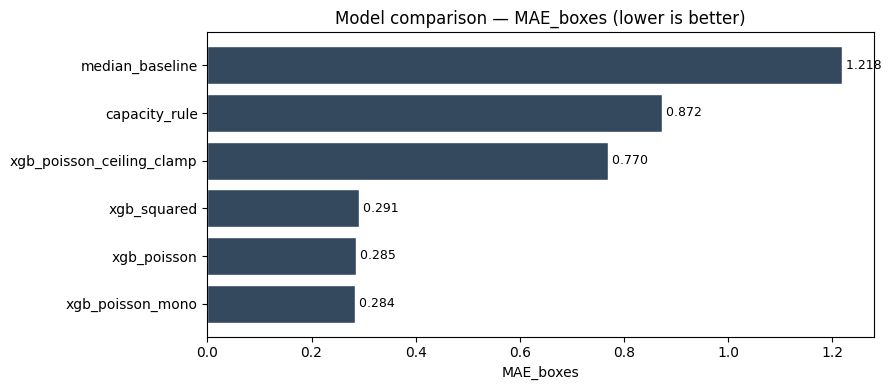

In [36]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_headline(results["headline"], metric="MAE_boxes", ax=ax)
plt.tight_layout(); plt.show()

## 11. Drill into a model — the stakeholder view

For the winner (lowest MAE), show the ⭐ per-band signed % error profile as a table, a stacked chart,
the per-band summary, and plain-language sentences you can paste into a deck. Swap `chosen` for any
model name to inspect a different one.

In [37]:
chosen = results["headline"].index[0]
display_section(f"PER-BAND SIGNED % ERROR PROFILE — {chosen}")
print("Rows = actual parcel band. Cells = % of orders in that band landing in each error bucket.")
display(results["band_profiles"][chosen])

display_section(f"PER-BAND SUMMARY — {chosen}")
display(results["band_summaries"][chosen].round(2))


PER-BAND SIGNED % ERROR PROFILE — xgb_poisson_mono
Rows = actual parcel band. Cells = % of orders in that band landing in each error bucket.


bucket,under >50%,under 20-50%,under 10-20%,under <10%,exact (0%),over <10%,over 10-20%,over 20-50%,over >50%
band,,,,,,,,,
1,0.0,0.0,0.0,0.0,88.4,0.0,0.0,0.0,11.6
2,1.4,0.0,0.0,0.0,92.5,0.0,0.0,0.0,6.0
3,0.1,11.9,0.0,0.0,77.3,0.0,0.0,10.3,0.4
4-5,1.0,25.2,0.0,0.0,54.3,0.0,0.0,18.7,0.8
6-10,0.3,9.7,32.0,0.0,40.0,0.0,15.4,2.5,0.1
11+,0.5,14.8,25.2,24.3,17.5,10.1,4.4,2.9,0.5



PER-BAND SUMMARY — xgb_poisson_mono


,n,actual_mean,pred_mean,mean_signed_pct,median_signed_pct,mape_pct,under_pct,exact_pct,over_pct,mae_boxes,share_of_orders_pct
band,,,,,,,,,,,
1,3654,1.00,1.13,13.16,0.00,13.16,0.00,88.37,11.63,0.13,3.97
2,35675,2.00,2.05,2.35,0.00,3.80,1.45,92.51,6.04,0.08,38.71
3,24983,3.00,2.99,-0.37,0.00,7.75,12.05,77.26,10.69,0.23,27.11
4-5,17725,4.39,4.32,-1.59,0.00,11.32,26.16,54.34,19.51,0.49,19.23
6-10,9453,6.99,6.67,-4.45,0.00,10.68,41.98,39.98,18.05,0.75,10.26
11+,663,13.53,12.32,-7.96,-9.09,13.27,64.71,17.50,17.80,1.93,0.72


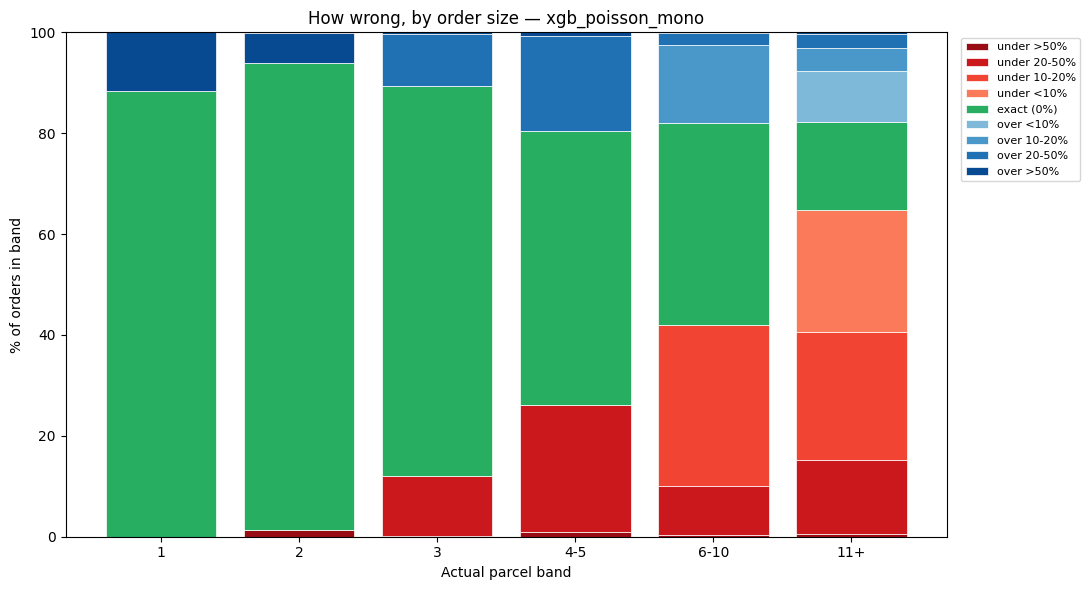

Plain-language read for a slide:
  • Band 1: 88% of the time 'exact (0%)'; 12% of the time 'over >50%'; 0% of the time 'under >50%'.
  • Band 2: 92% of the time 'exact (0%)'; 6% of the time 'over >50%'; 1% of the time 'under >50%'.
  • Band 3: 77% of the time 'exact (0%)'; 12% of the time 'under 20-50%'; 10% of the time 'over 20-50%'.
  • Band 4-5: 54% of the time 'exact (0%)'; 25% of the time 'under 20-50%'; 19% of the time 'over 20-50%'.
  • Band 6-10: 40% of the time 'exact (0%)'; 32% of the time 'under 10-20%'; 15% of the time 'over 10-20%'.
  • Band 11+: 25% of the time 'under 10-20%'; 24% of the time 'under <10%'; 18% of the time 'exact (0%)'.


In [38]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_band_profile(results["band_profiles"][chosen],
                  title=f"How wrong, by order size — {chosen}", ax=ax)
plt.tight_layout(); plt.show()

print("Plain-language read for a slide:")
prof = results["band_profiles"][chosen]
for b in prof.index:
    if prof.loc[b].notna().any():
        print("  • " + describe_band(prof.loc[b], b))

## 12. Hyperparameter search that feeds the same comparison

`tune_xgb()` runs your multi-objective grid on the validation slice and returns the configs ranked
by MAE. The best ones are turned straight into `XGBModel`s and dropped back into `compare_models`,
so tuning and evaluation share one code path.

In [43]:
# ============================================================
# HYPERPARAMETER SEARCH  — Optuna (TPE + MedianPruner), GPU-ready
# Quantizes train/val ONCE and reuses it across every trial (the big win at ~0.5M rows).
# ============================================================
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    _HAS_OPTUNA = True
except ImportError:
    _HAS_OPTUNA = False


class _OptunaPruneCallback(xgb.callback.TrainingCallback):
    """Report val metric to Optuna every `report_every` rounds; MedianPruner kills weak trials early."""
    def __init__(self, trial, report_every=25, data_name="val", metric="mae"):
        self.trial, self.k, self.dn, self.mn = trial, report_every, data_name, metric
    def after_iteration(self, model, epoch, evals_log):
        scores = evals_log.get(self.dn, {}).get(self.mn)
        if scores and (epoch + 1) % self.k == 0:
            self.trial.report(float(scores[-1]), epoch)
            if self.trial.should_prune():
                raise optuna.TrialPruned()
        return False


def tune_xgb(data, n_trials=120, timeout=None,
             objectives=("reg:squarederror", "count:poisson", "reg:absoluteerror"),
             num_boost_round=6000, early_stopping_rounds=50,
             device=XGB_DEVICE, monotone_features=(), report_every=25,
             random_state=RANDOM_STATE, verbose=True):
    """
    Rich Optuna search over learning_rate, depth, min_child_weight, subsample,
    colsample_by{tree,level}, reg_alpha/lambda, gamma, and objective.
    Train/val are quantized once (QuantileDMatrix) and shared by all trials.
    Returns COMPLETED trials ranked by val MAE. Falls back to randomized search if optuna is absent.
    """
    feats = data["feature_cols"]
    dtrain = xgb.QuantileDMatrix(data["X_train"][feats], label=data["y_train"])
    dval   = xgb.QuantileDMatrix(data["X_val"][feats],   label=data["y_val"], ref=dtrain)
    mono = tuple(1 if f in monotone_features else 0 for f in feats) if monotone_features else None
    base = {"tree_method": "hist", "device": device, "seed": random_state,
            "verbosity": 0, "eval_metric": "mae"}
    if mono is not None:
        base["monotone_constraints"] = mono

    def evaluate(params, trial=None):
        bp = {**base, **params}
        cbs = [_OptunaPruneCallback(trial, report_every)] if trial is not None else []
        bst = xgb.train(bp, dtrain, num_boost_round=num_boost_round,
                        evals=[(dval, "val")], early_stopping_rounds=early_stopping_rounds,
                        callbacks=cbs, verbose_eval=False)
        best_it = bst.best_iteration + 1
        pred = np.clip(bst.predict(dval, iteration_range=(0, best_it)), 0, None)
        mae = mean_absolute_error(data["y_val"], pred)
        del bst; gc.collect()
        return mae, best_it

    space = lambda t: {
        "objective":         t.suggest_categorical("objective", list(objectives)),
        "learning_rate":     t.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        "max_depth":         t.suggest_int("max_depth", 4, 12),
        "min_child_weight":  t.suggest_float("min_child_weight", 1.0, 256.0, log=True),
        "subsample":         t.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  t.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": t.suggest_float("colsample_bylevel", 0.5, 1.0),
        "reg_alpha":         t.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        t.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma":             t.suggest_float("gamma", 1e-3, 10.0, log=True),
    }

    if _HAS_OPTUNA:
        def objective(trial):
            mae, best_it = evaluate(space(trial), trial=trial)
            trial.set_user_attr("best_iter", best_it)
            return mae
        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=random_state, multivariate=True),
            pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=100,
                                               interval_steps=report_every))
        study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=verbose)
        rows = [{**t.params, "val_mae": t.value, "best_iter": t.user_attrs.get("best_iter")}
                for t in study.trials if t.state.name == "COMPLETE"]
        if verbose:
            n_pruned = sum(t.state.name == "PRUNED" for t in study.trials)
            print(f"  {len(rows)} completed, {n_pruned} pruned, best val MAE = {study.best_value:.4f}")
    else:  # randomized search over the same space, no pruning
        rng = np.random.default_rng(random_state)
        class _T:
            def suggest_categorical(s, n, c): return c[rng.integers(len(c))]
            def suggest_int(s, n, lo, hi): return int(rng.integers(lo, hi + 1))
            def suggest_float(s, n, lo, hi, log=False):
                return float(np.exp(rng.uniform(np.log(lo), np.log(hi)))) if log else float(rng.uniform(lo, hi))
        rows = []
        for i in range(n_trials):
            p = space(_T()); mae, best_it = evaluate(p)
            rows.append({**p, "val_mae": mae, "best_iter": best_it})
            if verbose and (i + 1) % 10 == 0:
                print(f"  [{i+1}/{n_trials}] tested")

    return pd.DataFrame(rows).sort_values("val_mae").reset_index(drop=True)


_TUNABLE = ["objective", "learning_rate", "max_depth", "min_child_weight",
            "subsample", "colsample_bytree", "colsample_bylevel",
            "reg_alpha", "reg_lambda", "gamma"]

def specs_from_tuning(tuning_df, top_k=3, predict_mode="round",
                      monotone_features=(), early_stopping_rounds=50):
    out = []
    for r in tuning_df.head(top_k).to_dict("records"):
        params = {k: r[k] for k in _TUNABLE if k in r and pd.notna(r[k])}
        if "max_depth" in params:
            params["max_depth"] = int(params["max_depth"])
        obj = params.get("objective", "reg").split(":")[-1]
        out.append(XGBModel(
            name=f"tuned_{obj}_d{params.get('max_depth','?')}_lr{round(params.get('learning_rate',0),3)}_{len(out)}",
            params=params, num_boost_round=int(r.get("best_iter") or 3000),
            early_stopping_rounds=early_stopping_rounds,
            predict_mode=predict_mode, monotone_features=monotone_features))
    return out


# ---- run it ----  (bump n_trials for the real 460k run; set XGB_DEVICE="cuda")
tuning = tune_xgb(data, n_trials=150, num_boost_round=6000)
display(tuning.head(10))

tuned_models = specs_from_tuning(tuning, top_k=3)
tuned_results = compare_models(tuned_models + [CapacityRuleBaseline()], data)
display(tuned_results["headline"])

  [10/150] tested
  [20/150] tested
  [30/150] tested
  [40/150] tested
  [50/150] tested
  [60/150] tested
  [70/150] tested
  [80/150] tested
  [90/150] tested
  [100/150] tested
  [110/150] tested
  [120/150] tested
  [130/150] tested
  [140/150] tested
  [150/150] tested


,objective,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,colsample_bylevel,reg_alpha,reg_lambda,gamma,val_mae,best_iter
0,reg:absoluteerror,0.023697,11,29.572024,0.776770,0.698083,0.838810,0.799979,0.185247,1.080660,0.311884,1175
1,reg:absoluteerror,0.011467,11,12.101060,0.946244,0.874809,0.995904,0.133553,0.436499,0.016215,0.312382,1291
2,reg:absoluteerror,0.041254,11,5.947838,0.874410,0.900695,0.745629,3.733568,0.003764,3.283032,0.312533,430
3,reg:absoluteerror,0.014963,12,111.760722,0.818537,0.560961,0.794129,0.555118,0.001120,0.065656,0.312750,3536
4,reg:absoluteerror,0.010882,12,21.729519,0.816988,0.552949,0.570170,0.047474,7.327025,0.242198,0.312764,2092
5,reg:absoluteerror,0.032143,9,10.289166,0.979605,0.875982,0.770428,0.013746,3.872462,0.008717,0.312871,941
6,reg:absoluteerror,0.066257,12,104.877242,0.995161,0.570798,0.724123,0.037178,0.002090,1.050318,0.313604,905
7,reg:absoluteerror,0.092034,11,86.530367,0.766361,0.816459,0.644078,0.870107,0.006451,0.601440,0.313664,438
8,reg:absoluteerror,0.085713,11,66.935605,0.677263,0.985349,0.946561,1.298775,0.006006,0.073601,0.314090,360
9,reg:absoluteerror,0.045264,9,179.457697,0.926992,0.661108,0.772274,0.091054,0.337917,0.021699,0.314242,2233


  training: tuned_absoluteerror_d11_lr0.024_0 ...
  training: tuned_absoluteerror_d11_lr0.011_1 ...
  training: tuned_absoluteerror_d11_lr0.041_2 ...
  training: capacity_rule ...


,MAE_boxes,RMSE_boxes,R2,MAPE_pct,median_abs_pct,bias_boxes,exact_pct,within_1_pct,under_pct,over_pct
model,,,,,,,,,,
tuned_absoluteerror_d11_lr0.024_0,0.286,0.636,0.888,7.417,0.000,-0.075,74.899,97.294,15.290,9.811
tuned_absoluteerror_d11_lr0.041_2,0.288,0.640,0.886,7.461,0.000,-0.077,74.795,97.248,15.402,9.803
tuned_absoluteerror_d11_lr0.011_1,0.289,0.642,0.886,7.507,0.000,-0.077,74.699,97.224,15.402,9.900
capacity_rule,0.872,1.308,0.526,28.973,33.333,-0.459,32.999,84.200,53.165,13.836


## 13. Permutation importance

Honest importance for any fitted `XGBModel`: shuffle each feature, measure the MAE increase.
Reuses the booster already trained inside `fit_predict`.

,feature,mae_increase,std
0,total_volume_l,0.547891,0.001729
1,fam_Surgelés,0.174891,0.000824
2,total_weight_net_g,0.165457,0.001135
3,n_distinct_affectations,0.108097,0.000469
4,aff_5_n,0.047535,0.000477
5,n_segregated_affectations,0.042935,0.000275
6,aff_6_n,0.018646,0.000173
7,n_unmatched,0.018588,0.000250
8,aff_8_n,0.018408,0.000333
9,fam_Charcuterie Traiteur,0.017698,0.000158


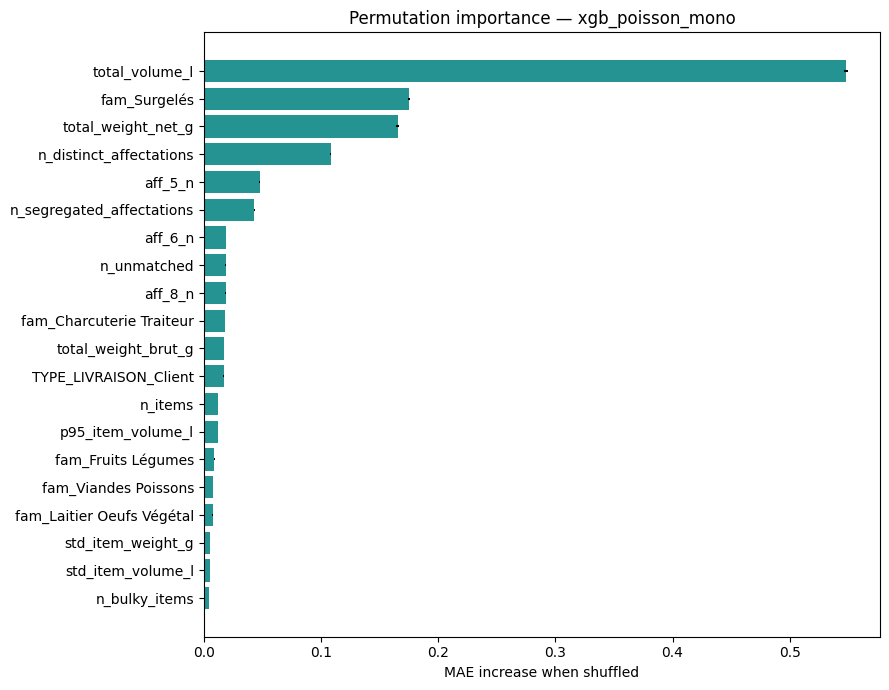

In [40]:
# ============================================================
# PERMUTATION IMPORTANCE  for a chosen fitted XGBModel
# ============================================================
def permutation_table(fitted_model, data, n_repeats=5, max_rows=50000):
    from sklearn.base import BaseEstimator, RegressorMixin
    feats = fitted_model.used_features
    class _W(RegressorMixin, BaseEstimator):
        def __init__(s, b=None): s.b = b
        def fit(s, X, y): return s
        def predict(s, X): return np.clip(s.b.predict(xgb.DMatrix(X)), 0, None)
    n = min(max_rows, len(data["X_test"]))
    sel = np.random.RandomState(RANDOM_STATE).choice(len(data["X_test"]), n, replace=False)
    Xp = data["X_test"][feats].iloc[sel]; yp = data["y_test"][sel]
    perm = permutation_importance(_W(fitted_model.booster), Xp, yp, n_repeats=n_repeats,
                                  random_state=RANDOM_STATE, scoring="neg_mean_absolute_error", n_jobs=1)
    return (pd.DataFrame({"feature": feats, "mae_increase": perm.importances_mean,
                          "std": perm.importances_std})
              .sort_values("mae_increase", ascending=False).reset_index(drop=True))

fitted = results["models"].get(chosen)
if isinstance(fitted, XGBModel) and fitted.booster is not None:
    perm_df = permutation_table(fitted, data)
    display(perm_df.head(20))
    top = perm_df.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top["feature"], top["mae_increase"], xerr=top["std"], color="teal", alpha=0.85)
    ax.set_xlabel("MAE increase when shuffled"); ax.set_title(f"Permutation importance — {chosen}")
    plt.tight_layout(); plt.show()
else:
    print(f"'{chosen}' is a baseline (no booster) — pick an XGBModel name to see importance.")

## 14. Export model, metadata & a reusable `prepare_features` template

Save the booster (JSON) and the metadata needed at inference, plus a template that turns raw order
lines + product dimensions into the exact model feature matrix. Adjust the merge keys / raw column
names to match your files.

In [41]:
# ============================================================
# EXPORT  (only meaningful for a fitted XGBModel)
# ============================================================
def export_model(fitted_model, export_dir, feature_cols, extra_metadata=None):
    os.makedirs(export_dir, exist_ok=True)
    model_path = os.path.join(export_dir, "parcel_prediction_xgb_model.json")
    meta_path  = os.path.join(export_dir, "parcel_prediction_metadata.pkl")
    fitted_model.booster.save_model(model_path)
    meta = {"feature_cols": list(feature_cols),
            "best_iteration": fitted_model.best_iteration,
            "params": fitted_model.params, "predict_mode": fitted_model.predict_mode}
    if extra_metadata:
        meta.update(extra_metadata)
    with open(meta_path, "wb") as f:
        pickle.dump(meta, f)
    print(f"Saved model -> {model_path}\nSaved metadata -> {meta_path}")
    return model_path, meta_path

# Example:
# if isinstance(fitted, XGBModel) and fitted.booster is not None:
#     export_model(fitted, MODEL_EXPORT_DIR, fitted.used_features)

In [42]:
# ============================================================
# REUSABLE PREPROCESSING TEMPLATE for inference on new orders
# ============================================================
def prepare_features(orders_df, produit_dim_df, metadata):
    """Turn raw order lines + product dimensions into the model's exact feature matrix.
    Adjust merge keys / column names to your raw schema."""
    df = orders_df.copy()
    if "ITEM_ID" in df.columns and "ITEM_ID" in produit_dim_df.columns:
        df = df.merge(produit_dim_df, on="ITEM_ID", how="left")

    aggs = df.groupby("ORDER_NUMBER").agg(
        n_items=("ORDER_NUMBER", "count"),
        total_weight_brut_g=("weight_brut_g", "sum") if "weight_brut_g" in df.columns else ("total_weight_brut_g", "first"),
        total_weight_net_g=("weight_net_g", "sum")   if "weight_net_g"  in df.columns else ("total_weight_net_g", "first"),
        total_volume_l=("volume_l", "sum")           if "volume_l"      in df.columns else ("total_volume_l", "first"),
        max_dim_cm=("length_cm", "max")              if "length_cm"     in df.columns else ("max_dim_cm", "first"),
    ).reset_index()

    aggs = engineer_features(aggs)                       # reuse the SAME engineering
    for col in metadata["feature_cols"]:                 # enforce schema
        if col not in aggs.columns:
            aggs[col] = 0
    return aggs[metadata["feature_cols"]].astype(np.float32)

print("prepare_features ready — pair it with export_model's metadata at inference time.")

prepare_features ready — pair it with export_model's metadata at inference time.
